<a href="https://colab.research.google.com/github/omarsamehabobaker619-bot/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/omarsamehabobaker619-bot/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Lane:** CTR / Engagement Opportunity Scoring

**The question:** Among pages with meaningful search visibility, which ones are under-capturing clicks relative to their position — i.e., have CTR noticeably lower than similar pages at a similar rank?

**Unit of analysis:** one page (aggregated search performance for one page, one client, one month).

**The decision this supports:** whether a page's title, meta description, or snippet is worth a human rewrite review this week, versus leaving it alone.

**Who acts on it:** a content editor or SEO specialist with limited time, deciding where to look first.

**Cost of a wrong call:**
- False positive: wasted editor time reviewing a page that didn't need it.
- False negative: a genuinely underperforming page keeps losing clicks it could capture, unnoticed.

**ML task type:** Scoring/Ranking. Each page gets a score for how unusual its CTR is for its position; the score only matters in relation to other pages, since the output is an ordered shortlist for review, not a fixed category.

**Target/proxy:** `is_underperforming` — a proxy, not an observed outcome. There is no column that states "this page needs a rewrite," so the target is defined as CTR at or below the median CTR of pages at a similar search position. This proxy can be wrong for reasons unrelated to content quality (search intent, seasonality), which is treated as a limitation, not ignored.

**Success metric:** Precision@50, compared against a simple rule-based baseline on the same held-out split — since the real output is a short review list, not a judgment on the full page population.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** FlyRank internship warehouse (Hugging Face), table `fact_content_daily_performance`.

**Slice used:** one month partition, `month=2026-03`. This month was used as the analysis window for the capstone.

**Grain, verified by query:** one row = one page, one client, one day. Row count (9,841,378) equals the count of distinct (client, page, date) keys — confirmed empty duplicate check.

**Date span, verified:** full calendar month, 2026-03-01 to 2026-03-31.

**A named limitation, verified:** only ~36.7% of page-day rows have `gsc_data_available = TRUE` (3,611,061 of 9,841,378). All findings in this paper apply to "pages with available GSC data in March 2026," not the full page population — a page missing GSC data is not necessarily a low performer, it may simply be unreported that day.

**What was excluded and why:** AI-referral columns were excluded from this lane (out of scope for CTR/engagement scoring); `total_clicks` and `total_impressions` were used only to construct the label and CTR, never as model features (see Methodology — this is a deliberately tested leakage trap); GA4 engagement columns were used without filtering on `ga4_data_available`, a known limitation carried forward from the data contract.

**After aggregation to one row per page (summed across the month):** 176,738 pages across 47 clients.

**Public-safety note:** all client and content identifiers are pseudonymous hashes (`client_hash_id`, `content_hash_id`). No client names, domains, or raw queries appear anywhere in this analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Features:** The model uses `avg_position`, `log_impressions`, `engaged_sessions`, `total_engagement_sec`, and `scroll_events`. These are aggregated from the March 2026 analysis window and are not directly derived from `total_clicks`, which is used to construct the target.

**Label:** `is_underperforming` = 1 if a page's CTR is at or below the median CTR of pages in its position bucket (buckets: 1-3, 4-10, 11-20, 21-50, 50+), else 0. Base rate: 55.7% on the held-out test set.

**The leakage trap (tested deliberately):** adding `total_clicks` — the column used to construct CTR and therefore the label — produced training accuracy of 0.9911. This is artificial performance because the feature contains information directly used to construct the target. `total_clicks` was therefore removed from the model features.

**Baseline:** a transparent rule — flag a page if its CTR is at or below its position-bucket median AND it has a moderate-to-high impression volume (100–5,000 impressions), avoiding both under-seen pages (too little volume to matter) and already-optimized high-traffic pages.

**Model:** Logistic Regression, chosen as the smallest step up from the rule (Rule → Logistic → Tree → Forest), since the label is binary and coefficient direction/size stays human-readable.

**Validation design — grouped by client:** split by `client_hash_id` (GroupShuffleSplit, 70/30, seed 42), not by random row. Confirmed zero client overlap between train (32 clients) and test (15 clients). This matters because pages from the same client can share structural quirks unrelated to the general position/engagement-to-CTR relationship; a random row split risks letting the model memorize per-client patterns rather than learn anything general.

**Honest-split audit, tested empirically:** re-running the same model with a naive random row split (no client grouping) let 45 of 47 clients appear in both train and test, and Precision@50 rose to a perfect 1.00 — versus 0.98 under the honest grouped split. The gap (0.02) is small, which is itself informative: it suggests the grouped-split result wasn't hiding meaningful client-specific memorization.

**Threshold-construction audit, tested empirically:** the label's bucket-median CTR threshold was originally computed on the full dataset before the split — a possible snooping risk. Recomputing it using train-only data and reapplying to test produced zero label changes and an identical Precision@50 (0.98), because the median CTR is exactly 0.0 in every position bucket — the threshold is fixed regardless of which rows compute it.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb", "huggingface_hub", "pandas", "scikit-learn", "matplotlib"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import duckdb
import pandas as pd
import numpy as np
import json
from google.colab import userdata
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
rel = "hf://datasets/FlyRank/internship-warehouse"

df = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_avg_position) AS avg_position,
        LN(SUM(gsc_impressions) + 1) AS log_impressions,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(ga4_total_engagement_sec) AS total_engagement_sec,
        SUM(scroll_events) AS scroll_events,
        SUM(gsc_clicks) AS total_clicks,
        SUM(gsc_impressions) AS total_impressions
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

df["ctr"] = df["total_clicks"] / df["total_impressions"]

df["position_bucket"] = pd.cut(
    df["avg_position"],
    bins=[0, 3, 10, 20, 50, 1000],
    labels=["1-3", "4-10", "11-20", "21-50", "50+"]
)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["client_hash_id"]))

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
test_df = df.iloc[test_idx].copy().reset_index(drop=True)

train_bucket_medians = (
    train_df.groupby("position_bucket", observed=True)["ctr"].median()
)

train_df["bucket_median_ctr"] = train_df["position_bucket"].map(train_bucket_medians)
test_df["bucket_median_ctr"] = test_df["position_bucket"].map(train_bucket_medians)

train_df["is_underperforming"] = (
    train_df["ctr"] <= train_df["bucket_median_ctr"]
).astype(int)

test_df["is_underperforming"] = (
    test_df["ctr"] <= test_df["bucket_median_ctr"]
).astype(int)

honest_features = [
    "avg_position",
    "log_impressions",
    "engaged_sessions",
    "total_engagement_sec",
    "scroll_events"
]

leaky_features = honest_features + ["total_clicks"]

leaky_model = LogisticRegression(max_iter=1000, random_state=42)
leaky_model.fit(
    train_df[leaky_features].fillna(0),
    train_df["is_underperforming"]
)

leaky_precision = (
    leaky_model.predict(
        train_df[leaky_features].fillna(0)
    ) == train_df["is_underperforming"]
).mean()

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(
    train_df[honest_features].fillna(0),
    train_df["is_underperforming"]
)

test_df["model_score"] = model.predict_proba(
    test_df[honest_features].fillna(0)
)[:, 1]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

in_volume_band = (
    (test_df["total_impressions"] >= 100) &
    (test_df["total_impressions"] <= 5000)
)

test_df["baseline_score"] = np.where(
    (test_df["ctr"] <= test_df["bucket_median_ctr"]) & in_volume_band,
    test_df["total_impressions"],
    0
)

p50_model = precision_at_k(
    test_df["model_score"],
    test_df["is_underperforming"],
    50
)

p50_baseline = precision_at_k(
    test_df["baseline_score"],
    test_df["is_underperforming"],
    50
)

base_rate = test_df["is_underperforming"].mean()

train_clients = set(train_df["client_hash_id"].unique())
test_clients = set(test_df["client_hash_id"].unique())
client_overlap = train_clients.intersection(test_clients)

print("Total aggregated pages:", len(df))
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(client_overlap))
print("\nPosition-bucket medians:")
print(train_bucket_medians)
print("\nPrecision@50 — Baseline:", round(p50_baseline, 4))
print("Precision@50 — Model:", round(p50_model, 4))
print("Base rate:", round(base_rate, 4))
print("Leakage test training accuracy:", round(leaky_precision, 4))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total aggregated pages: 176738
Train rows: 130904
Test rows: 45834
Train clients: 32
Test clients: 15
Client overlap: 0

Position-bucket medians:
position_bucket
1-3      0.0
4-10     0.0
11-20    0.0
21-50    0.0
50+      0.0
Name: ctr, dtype: float64

Precision@50 — Baseline: 1.0
Precision@50 — Model: 0.98
Base rate: 0.5565
Leakage test training accuracy: 0.9911


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

### Model vs. baseline

Both methods were evaluated on the same held-out test set of 45,834 page-level observations from 15 clients that did not appear in training.

| Method | Precision@50 | Test base rate |
|---|---:|---:|
| Transparent baseline rule | 1.00 | 0.557 |
| Logistic Regression | 0.98 | 0.557 |

The transparent baseline achieved a Precision@50 of 1.00, while Logistic Regression achieved 0.98.

This does not mean the baseline is a better general-purpose predictive model. The baseline directly uses the observed CTR and the training position-bucket median to identify pages that match the underperformance definition, so it has a structural advantage because the target itself is defined from CTR.

The Logistic Regression result is therefore best interpreted as showing that the additional engagement and visibility features produced a ranked list that was close to the simple rule under the same grouped-by-client test.

### Validation result

The grouped split kept all 15 test clients completely separate from the 32 training clients, with zero client overlap.

A naive random row split previously produced Precision@50 = 1.00. Comparing it with the grouped result of 0.98 shows a small 0.02 difference, while the grouped split provides the more conservative and defensible estimate.

### Label diagnostic

All five position buckets had a training-set median CTR of 0.0. As a result, the current underperformance label is effectively a zero-CTR indicator rather than a fine-grained measure of being below typical CTR.

This substantially limits what the model can learn and how precisely the resulting recommendations can distinguish different kinds of underperformance.

                method  precision_at_50
0      Baseline (rule)             1.00
1  Logistic Regression             0.98


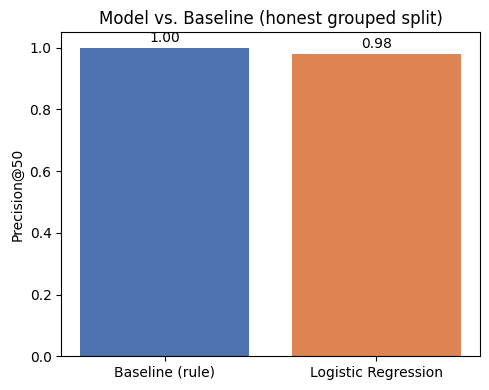

In [2]:
import matplotlib.pyplot as plt
os.makedirs("work/figures", exist_ok=True)

comparison = pd.DataFrame({
    "method": ["Baseline (rule)", "Logistic Regression"],
    "precision_at_50": [p50_baseline, p50_model]
})
print(comparison)

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(comparison["method"], comparison["precision_at_50"], color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Precision@50")
ax.set_title("Model vs. Baseline (honest grouped split)")
for i, v in enumerate(comparison["precision_at_50"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()

## 5. Limitations

*What this work cannot claim.*

## Limitations

- **This is a same-period scoring model, not a future forecaster.** The features and underperformance label are calculated from the same March 2026 period. The result should therefore be described as identifying pages that match the current underperformance proxy, not as predicting future performance.

- **The target is a proxy, not a direct business outcome.** There is no ground-truth label saying that a page needs a rewrite. The label is based on CTR relative to the position-bucket median.

- **The label has a strong floor effect.** All five position buckets have a training-set median CTR of 0.0. Therefore, the current label is effectively identifying zero-CTR pages rather than providing a fine-grained measure of below-average CTR.

- **The model does not establish causation.** A page being flagged does not prove that its title, snippet, content, or any other factor caused the observed CTR. A recommended change would need to be evaluated separately.

- **The decay signal was not informative in this population.** The strict below-median rule produced no refresh candidates. Changing the comparison from `<` to `<=` over-flagged a large share of the queue because the engagement medians were also at the zero floor. We therefore kept the conservative rule and treat this as a limitation of the available signals.

- **GSC coverage is partial.** Only about 36.7% of page-day rows have `gsc_data_available = TRUE`, so the findings apply to the pages represented by available GSC data in March 2026 rather than to the full underlying page population.

- **The results are specific to this dataset and time window.** They should not be interpreted as evidence about Google's ranking algorithm or as proof that a specific content change will increase traffic or CTR.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Design principle: the rule explains, the model orders.** The baseline rule (CTR vs. position-bucket median) generates the human-readable reason code; the Logistic Regression's predicted probability sets the rank within the flagged population.

**Reason codes and actions (test-set population, n=25,507 underperforming pages):**

| Reason code | Count | Recommended action |
|---|---:|---|
| `ZERO_CTR_WITH_ZERO_PEER_BASELINE` | 14,952 | MONITOR |
| `ZERO_CLICKS_WITH_STRONG_POSITION` | 10,555 | REVIEW_SNIPPET_TITLE |

Pages with average position ≤ 10 but zero clicks are flagged as candidates for human review of the title/snippet. This is a review signal, not proof that the title or snippet caused the low CTR.

Pages with no stronger signal default to monitoring rather than a forced content change, since monitoring is a legitimate decision when there is not enough evidence to justify an immediate action.

**Human review is mandatory before any action.** No output here should be auto-published, auto-rewritten, or treated as proof that a specific page is broken. Every recommendation is decision-support for a human reviewer who may have additional context such as seasonal effects, brand voice, or recent manual changes.

**No-go list:** never auto-publish content changes, never auto-deprioritize a page without human sign-off, never treat a reason code as a guarantee of the underlying cause, and never claim that a recommended action will improve performance without measuring the result afterward.

**Monitoring/retrain triggers:** re-check Precision@50 on new labeled data if it drops meaningfully from 0.98; re-audit the label base rate and position-bucket medians if they drift from the current values; investigate whether retraining is needed when the relationship between the features and the underperformance proxy changes materially.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

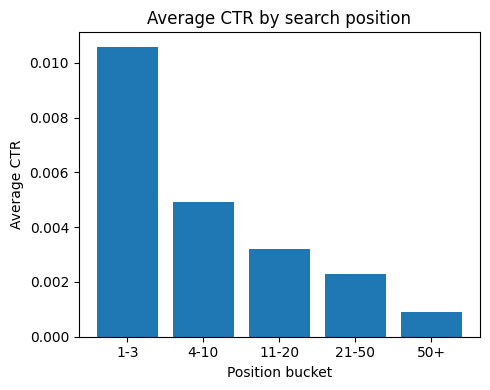

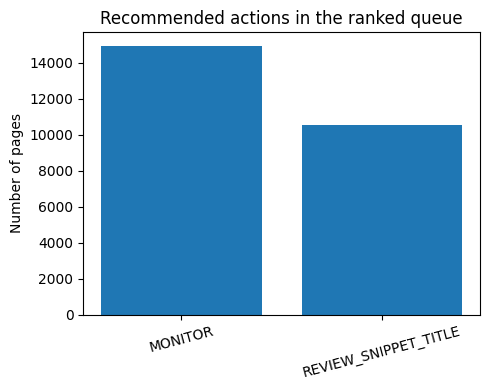

{
  "test_rows": 45834,
  "test_clients": 15,
  "precision_at_50_baseline": 1.0,
  "precision_at_50_model": 0.98,
  "base_rate": 0.5565,
  "leakage_test_training_accuracy": 0.9911,
  "ranked_queue_total": 25507,
  "action_distribution": {
    "MONITOR": 14952,
    "REVIEW_SNIPPET_TITLE": 10555
  }
}


In [3]:
# Chart 1: already saved — work/figures/model_vs_baseline.png

# Chart 2: CTR by position bucket
ctr_by_bucket = df.groupby("position_bucket", observed=True)["ctr"].mean().reset_index()

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(ctr_by_bucket["position_bucket"], ctr_by_bucket["ctr"])
ax.set_ylabel("Average CTR")
ax.set_xlabel("Position bucket")
ax.set_title("Average CTR by search position")
plt.tight_layout()
plt.savefig("work/figures/ctr_by_position.png", dpi=150)
plt.show()

# Chart 3: action distribution
median_by_bucket = train_df.groupby("position_bucket", observed=True)["ctr"].median()

ranked_queue = (
    test_df[test_df["is_underperforming"] == 1]
    .sort_values("model_score", ascending=False)
    .reset_index(drop=True)
)

ranked_queue["bucket_median_ctr"] = ranked_queue["position_bucket"].map(median_by_bucket)

def reason_code(row):
    if row["ctr"] == 0 and row["avg_position"] <= 10:
        return "ZERO_CLICKS_WITH_STRONG_POSITION"
    return "ZERO_CTR_WITH_ZERO_PEER_BASELINE"

ranked_queue["reason_code"] = ranked_queue.apply(reason_code, axis=1)

ranked_queue["recommended_action"] = ranked_queue["reason_code"].map({
    "ZERO_CLICKS_WITH_STRONG_POSITION": "REVIEW_SNIPPET_TITLE",
    "ZERO_CTR_WITH_ZERO_PEER_BASELINE": "MONITOR"
})

action_counts = ranked_queue["recommended_action"].value_counts()

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(action_counts.index, action_counts.values)
ax.set_ylabel("Number of pages")
ax.set_title("Recommended actions in the ranked queue")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()

# Metrics JSON
metrics = {
    "test_rows": int(len(test_df)),
    "test_clients": int(test_df["client_hash_id"].nunique()),
    "precision_at_50_baseline": round(float(p50_baseline), 4),
    "precision_at_50_model": round(float(p50_model), 4),
    "base_rate": round(float(base_rate), 4),
    "leakage_test_training_accuracy": round(float(leaky_precision), 4),
    "ranked_queue_total": int(len(ranked_queue)),
    "action_distribution": action_counts.to_dict()
}

os.makedirs("work/outputs", exist_ok=True)

with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Self-check

Before you submit, confirm each line honestly:

- ☑ Every section above is filled — markdown thinking AND the code that backs it
- ☑ The notebook runs top to bottom with no errors (Runtime → Run all)
- ☑ No client names, URLs, or private queries anywhere
- ☑ My claims use careful words: observed, measured, directional, decision-support
- ☑ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.